# 003 — El modelo de pronóstico, tal cual lo entrega la aplicación

Este notebook entrena y evalúa el modelo de pronóstico de VigIA **con el código de
producción** ([`ml/vigia/ml/forecasting.py`](../ml/vigia/ml/forecasting.py)): el mismo
`forecasting.train()` que ejecuta `vigia train` y el mismo `forecasting.predict()` que
responde a la pestaña *Pronóstico*. No hay lógica duplicada ni simplificada.

**El modelo en una frase:** un único `HistGradientBoostingRegressor` **global** aprende de
las ~13.000 series `municipio × categoría` a la vez (comparte señal entre territorios y
cubre municipios con poca historia), modela **tasas por 100.000 habitantes** (población
DANE) y **entrega conteos**; la predicción que recibe el usuario es una **mezcla 0,7·modelo +
0,3·persistencia** que estabiliza las mega-ciudades. Se valida con **backtest walk-forward
recursivo** (sin fuga de datos) contra dos líneas base (persistencia y estacional), con
banda de incertidumbre **calibrada empíricamente** (cobertura 80 %).

**Dos advertencias de reproducibilidad:**

1. **Versiones.** La producción fija `scikit-learn >=1.9,<1.10` (`ml/pyproject.toml`); si este
   entorno tiene otra versión, las métricas serán *cercanas pero no idénticas* al reporte
   versionado. Además, el *early stopping* del boosting es sensible a las reducciones de punto
   flotante multi-hilo: las métricas fluctúan **~1 % entre ejecuciones** aun con `SEED=77`
   (detalle en [docs/CRISP-ML-Q.md](../docs/CRISP-ML-Q.md#3-ingeniería-del-modelo)).
2. **Aislamiento del artefacto.** `train()` persiste el modelo en `models/`, que es un
   *bind mount* compartido con el contenedor: un joblib escrito con otra versión de
   scikit-learn dejaría **ilegible** el modelo del servicio (incidente 2026-07: la API
   respondía 503). Por eso la primera celda **redirige el artefacto** a
   `notebooks/artefactos/` — la misma protección que usa `ml/tests/conftest.py`.

In [1]:
import sys
from pathlib import Path

# El paquete se instala con `cd ml && pip install -e ".[dev]"`; si no está instalado,
# se usa directamente desde el repositorio (el notebook vive en notebooks/).
try:
    import vigia  # noqa: F401
except ModuleNotFoundError:
    for base in (Path.cwd(), Path.cwd().parent):
        if (base / "ml" / "vigia").exists():
            sys.path.insert(0, str(base / "ml"))
            break
import json

import numpy as np
import pandas as pd
import sklearn

from vigia.config import settings
from vigia.ml import forecasting
from vigia.ml.features import LAGS, TARGET, feature_columns, make_features

pd.set_option("display.max_columns", 40)
print("Python", sys.version.split()[0], "· scikit-learn", sklearn.__version__,
      "· numpy", np.__version__, "· pandas", pd.__version__, "· SEED =", settings.seed)

Python 3.13.9 · scikit-learn 1.7.2 · numpy 2.3.5 · pandas 2.3.3 · SEED = 77


In [2]:
# ── Aislamiento del artefacto (OBLIGATORIO antes de entrenar) ─────────────────────────
# models/forecaster.joblib pertenece al contenedor; este notebook escribe el suyo en
# notebooks/artefactos/ (gitignored). Es la misma redirección que hace ml/tests/conftest.py.
ARTEFACTOS = settings.data_dir.parent / "notebooks" / "artefactos"
ARTEFACTOS.mkdir(parents=True, exist_ok=True)
forecasting.MODEL_PATH = ARTEFACTOS / "forecaster_nb.joblib"
forecasting.META_PATH = forecasting.MODEL_PATH.with_suffix(".meta.json")

assert forecasting.MODEL_PATH.parent != settings.models_dir, "¡El artefacto apunta a models/!"
print("Artefacto del notebook →", forecasting.MODEL_PATH)

Artefacto del notebook → D:\GitHub\vigia\notebooks\artefactos\forecaster_nb.joblib


## 1. La serie de entrada: gold `serie_mensual`

El entrenamiento consume el mismo artefacto que la CLI (`vigia train` en
[`ml/vigia/cli.py`](../ml/vigia/cli.py)): la serie mensual `municipio × categoría` de la capa
gold, con calendario continuo **por serie** (los huecos internos son ceros legítimos; no se
inventan años de ceros antes de que la serie exista) y la **población DANE** cruzada por
municipio-año. El panel incluye las series de naturaleza *respuesta* (el modelo global
aprende de todas; quien las excluye es la detección de anomalías, una decisión de producto
distinta).

In [3]:
serie = pd.read_parquet(settings.gold_dir / "serie_mensual.parquet")
n_series = serie.groupby(["cod_municipio", "categoria"]).ngroups
print(f"{len(serie):,} filas · {n_series:,} series · "
      f"{serie['cod_municipio'].nunique():,} municipios · "
      f"{serie['categoria'].nunique()} categorías · "
      f"{serie['periodo'].min():%Y-%m} → {serie['periodo'].max():%Y-%m}".replace(",", "."))
serie.head(3)

3.282.006 filas · 18.262 series · 1.126 municipios · 20 categorías · 2003-01 → 2026-05


,periodo,cantidad,cod_municipio,municipio,cod_departamento,departamento,categoria,anio,mes,poblacion,naturaleza
0,2010-01-01,11,05001,MEDELLÍN,05,ANTIOQUIA,AMENAZAS,2010,1,2185539,delito
1,2010-02-01,9,05001,MEDELLÍN,05,ANTIOQUIA,AMENAZAS,2010,2,2185539,delito
2,2010-03-01,5,05001,MEDELLÍN,05,ANTIOQUIA,AMENAZAS,2010,3,2185539,delito


## 2. Filtrado de series activas

Se modelan solo las series con **≥ 12 meses no nulos**: en series casi vacías (conteos
minúsculos y esporádicos) el pronóstico no aporta y la línea base ingenua es imbatible por
construcción — incluirlas distorsionaría las métricas sin mejorar ninguna decisión.

In [4]:
activas = forecasting._filter_active_series(serie, min_nonzero=12)
n_act = activas.groupby(["cod_municipio", "categoria"]).ngroups
print(f"Series totales:   {n_series:,}".replace(",", "."))
print(f"Series modeladas: {n_act:,} "
      f"({100 * n_act / n_series:.1f} % de las series, "
      f"{100 * activas['cantidad'].sum() / serie['cantidad'].sum():.1f} % de los hechos)".replace(",", "."))

Series totales:   18.262
Series modeladas: 13.089 (71.7 % de las series. 99.8 % de los hechos)


## 3. Ingeniería de features (sin fuga de datos)

`make_features` ([`ml/vigia/ml/features.py`](../ml/vigia/ml/features.py)) construye, para
cada serie: **rezagos** (1, 2, 3, 6, 12), **medias/desviaciones móviles** (3, 6, 12, sobre
el valor de t−1), **identidad de la serie** (`media_hist` con ventana de 60 meses — no expansiva, para no arrastrar épocas superadas en series con caída secular —, `meses_activos`),
**estacionalidad de calendario** (mes, trimestre, seno/coseno) y **tendencia**. Con
población disponible añade las exógenas `log_poblacion` y `tasa_hist`. Todas las features en
`t` usan solo información hasta `t−1` — la condición para que el backtest sea honesto.

In [5]:
bogota = serie[(serie["cod_municipio"] == "11001") & (serie["categoria"] == "HOMICIDIO")]
fb = make_features(bogota)
cols_demo = ["periodo", "cantidad", "lag_1", "lag_12", "roll_mean_3", "roll_mean_12",
             "media_hist", "log_poblacion", "tasa_hist", "mes_sin", "trend"]
fb[cols_demo].tail(6)

,periodo,cantidad,lag_1,lag_12,roll_mean_3,roll_mean_12,media_hist,log_poblacion,tasa_hist,mes_sin,trend
470416,2025-12-01,107,97.0,115.0,93.333333,99.500000,93.783333,15.887159,1.181463,-2.449294e-16,276
470417,2026-01-01,91,107.0,98.0,101.000000,98.833333,93.783333,15.886889,1.181782,5.000000e-01,277
470418,2026-02-01,85,91.0,80.0,98.333333,98.250000,94.033333,15.886889,1.184933,8.660254e-01,278
470419,2026-03-01,92,85.0,104.0,94.333333,98.666667,94.166667,15.886889,1.186613,1.000000e+00,279
470420,2026-04-01,89,92.0,102.0,89.333333,97.666667,94.450000,15.886889,1.190183,8.660254e-01,280
470421,2026-05-01,97,89.0,104.0,88.666667,96.583333,94.516667,15.886889,1.191023,5.000000e-01,281


## 4. El objetivo de modelado: tasas por 100.000 habitantes

Con población DANE disponible, `train` detecta el modo `rate` y transforma el objetivo:
modelar la **tasa** iguala la escala entre Bogotá y un municipio pequeño (misma unidad
epidemiológica) y mejoró MAE y sMAPE frente a modelar conteos (bitácora, Iteración 8). El
pronóstico **siempre se entrega en conteos** (se reconvierte con la población). La alternativa
`loss="poisson"` se re-probó y **explota** en la recursión multipaso (errores ~1e73): la
escala se resuelve con tasas, no cambiando la pérdida.

In [6]:
modo = "rate" if forecasting._has_population(activas) else "count"
print("Modo de modelado detectado:", modo)

tasa = forecasting._as_modeling_target(bogota, "rate")
pd.DataFrame({
    "periodo": bogota["periodo"].dt.strftime("%Y-%m").tail(4).to_numpy(),
    "conteo (se entrega)": bogota["cantidad"].tail(4).to_numpy(),
    "poblacion (DANE)": bogota["poblacion"].tail(4).to_numpy(),
    "tasa por 100.000 (se modela)": tasa["cantidad"].tail(4).round(3).to_numpy(),
})

Modo de modelado detectado: rate


,periodo,conteo (se entrega),poblacion (DANE),tasa por 100.000 (se modela)
0,2026-02,85,7935754,1.071
1,2026-03,92,7935754,1.159
2,2026-04,89,7935754,1.122
3,2026-05,97,7935754,1.222


## 5. Validación: backtest walk-forward recursivo, sin fuga

Para cada uno de los 3 **orígenes temporales** se entrena un estimador solo con el pasado y
se pronostican 6 meses **de forma recursiva** — realimentando cada predicción, exactamente
como `predict` en producción — contra los valores reales. Las varas de comparación:

- **Persistencia** (línea base ingenua): repetir el último valor observado.
- **Estacional-ingenua**: el mismo mes del año anterior.
- **MASE** (métrica de cabecera): MAE escalado por el error ingenuo de cada serie —
  adimensional y estable en conteos dispersos, donde el sMAPE se degenera.

La **predicción entregada** que se evalúa es la mezcla `0,7·modelo + 0,3·persistencia`
(`_BLEND_W`), y la **banda de incertidumbre** se calibra sobre los residuos fuera de muestra
para que la cobertura empírica iguale el 80 % nominal (estilo conformal). Los
hiperparámetros están confirmados por una búsqueda con **CV temporal** (no k-fold aleatorio,
que filtraría el futuro; bitácora, Iteración 9):

In [7]:
print("Hiperparámetros de producción (_HGB_PARAMS):", forecasting._HGB_PARAMS)
print("Peso del modelo en la mezcla entregada (_BLEND_W):", forecasting._BLEND_W)
print("Nivel nominal de la banda (_PI_LEVEL):", forecasting._PI_LEVEL, "%")

Hiperparámetros de producción (_HGB_PARAMS): {'max_iter': 400, 'learning_rate': 0.05, 'max_depth': 8, 'l2_regularization': 1.0}
Peso del modelo en la mezcla entregada (_BLEND_W): 0.7
Nivel nominal de la banda (_PI_LEVEL): 80 %


## 6. Entrenamiento (idéntico a `vigia train`)

La llamada es la misma de la CLI: `forecasting.train(serie, test_months=6)` — backtest de 3
orígenes a horizonte 6 y reentrenamiento final con TODO el histórico. Sobre el panel
completo tarda **varios minutos** (el backtest recalcula las features en cada paso de la
recursión).

In [8]:
%%time
modelo = forecasting.train(serie, test_months=6)
print("\nEntrenado:", modelo.trained_at, "· modo:", modelo.target_mode,
      "· features:", len(modelo.feature_cols))

[16:41:37] INFO     Target de modelado: rate (19 features)

[17:10:34] INFO     Backtest walk-forward recursivo (3 orígenes, h=6): sMAPE 1-paso modelo=127.30 vs base=120.13 | 
                    multipaso modelo=115.02 vs base=116.90 | cobertura PI=80.0%

[17:12:45] INFO     Top features (permutación): roll_mean_12=1.4063, media_hist=0.6838, lag_1=0.1418,              
                    roll_mean_3=0.116, roll_mean_6=0.1101

[17:12:46] INFO     Modelo guardado en D:\GitHub\vigia\notebooks\artefactos\forecaster_nb.joblib (sklearn 1.7.2,   
                    numpy 2.3.5)


Entrenado: 2026-07-07T22:12:45.962731+00:00 · modo: rate · features: 19
CPU times: total: 23min 35s
Wall time: 32min 20s


## 7. Métricas del backtest

`mae`/`mase` frente a las dos líneas base, a 1 paso (cabecera) y sobre el horizonte completo
que se entrega (multipaso), con su degradación por paso y el desglose por tercil de volumen — el
desglose que reconcilia el agregado: la persistencia es casi imbatible en volumen ínfimo,
mientras el modelo gana donde hay señal recurrente, que es donde la prevención importa.

In [9]:
m = modelo.metrics
cab = pd.DataFrame({
    "modelo (entregado)": [m["mae"], m["mase"], m["smape"]],
    "persistencia": [m["baseline_mae"], m["baseline_mase"], m["baseline_smape"]],
    "estacional": [m["baseline_estacional_mae"], None, m["baseline_estacional_smape"]],
}, index=["MAE (1 paso)", "MASE (1 paso)", "sMAPE (1 paso)"])
display(cab.round(4))
print(f"Mejora de MAE vs persistencia: {m['skill_mae_vs_persistencia_pct']} % · "
      f"vs estacional: {m['skill_mae_vs_estacional_pct']} % · "
      f"cobertura empírica de la banda: {m['pi_cobertura_empirica_pct']} % (nominal 80 %)")

mp = m["multipaso"]
print(f"\nMultipaso (h={mp['horizon']}): MAE {mp['mae']} vs persistencia {mp['baseline_mae']} "
      f"vs estacional {mp['baseline_estacional_mae']} · MASE {mp['mase']} vs {mp['baseline_mase']}")
display(pd.DataFrame(mp["por_paso"])[["paso", "mae", "baseline_mae", "mase", "baseline_mase"]].round(4))
display(pd.DataFrame(m["por_volumen"])[["estrato", "rango_volumen_mensual", "mae", "baseline_mae", "smape", "baseline_smape", "gana_modelo"]])

,modelo (entregado),persistencia,estacional
MAE (1 paso),2.5225,2.5968,2.7168
MASE (1 paso),1.3446,1.4489,NaN
sMAPE (1 paso),127.3000,120.1300,123.3000


Mejora de MAE vs persistencia: 2.9 % · vs estacional: 7.2 % · cobertura empírica de la banda: 80.0 % (nominal 80 %)

Multipaso (h=6): MAE 2.9217 vs persistencia 3.4778 vs estacional 3.2028 · MASE 1.4678 vs 1.664


,paso,mae,baseline_mae,mase,baseline_mase
0,1,2.5225,2.5968,1.3446,1.4489
1,2,3.0939,3.5499,1.3904,1.5380
2,3,3.0536,3.7091,1.4178,1.6190
3,4,2.7785,3.4621,1.5178,1.7640
4,5,2.9516,3.7799,1.6027,1.8668
5,6,3.3973,4.4156,1.7247,2.0299


,estrato,rango_volumen_mensual,mae,baseline_mae,smape,baseline_smape,gana_modelo
0,bajo,≤0.4,0.5081,0.5111,173.25,167.89,False
1,medio,0.4–1.2,0.8969,1.0342,133.22,139.58,True
2,alto,>1.2,6.1625,6.2450,75.43,82.80,True


## 8. Contraste con el reporte versionado de producción

[reports/model_report.json](../reports/model_report.json) es la instantánea auditable del
último entrenamiento del pipeline (dentro del contenedor, con el scikit-learn del pin). Las
cifras de este notebook deben quedar **cerca, no idénticas**: cambia la versión de
scikit-learn y actúa el ruido multi-hilo (~1 %); como la mejora frente a la persistencia es
una diferencia entre cantidades casi iguales, ese ruido la mueve en puntos porcentuales
(por eso la documentación la declara como banda «+1 a +3 %»). **Si una cifra difiere,
prevalece el reporte regenerado por el pipeline.**

In [10]:
prod = json.loads((settings.reports_dir / "model_report.json").read_text(encoding="utf-8"))
pm, pmp = prod["metricas_backtest"], prod["metricas_backtest"]["multipaso"]
comparacion = pd.DataFrame({
    "este notebook": [m["mae"], m["baseline_mae"], m["mase"], mp["mae"], mp["baseline_mae"],
                      m["pi_cobertura_empirica_pct"], m["skill_mae_vs_persistencia_pct"]],
    "producción (versionado)": [pm["mae"], pm["baseline_mae"], pm["mase"], pmp["mae"], pmp["baseline_mae"],
                                pm["pi_cobertura_empirica_pct"], pm["skill_mae_vs_persistencia_pct"]],
}, index=["MAE 1 paso", "MAE persistencia", "MASE 1 paso", "MAE multipaso",
          "MAE persistencia multipaso", "cobertura banda (%)", "mejora vs persistencia (%)"])
comparacion.round(4)

,este notebook,producción (versionado)
MAE 1 paso,2.5225,2.5453
MAE persistencia,2.5968,2.5968
MASE 1 paso,1.3446,1.3467
MAE multipaso,2.9217,2.9195
MAE persistencia multipaso,3.4778,3.4778
cobertura banda (%),80.0000,80.0000
mejora vs persistencia (%),2.9000,2.0000


## 9. Interpretabilidad: importancia por permutación

`HistGradientBoostingRegressor` no expone importancias nativas; se mide la **caída de MAE al
barajar cada feature** (agnóstico al modelo, sobre una muestra). El rezago inmediato y la
identidad/escala de la serie dominan — coherente con un panel autorregresivo.

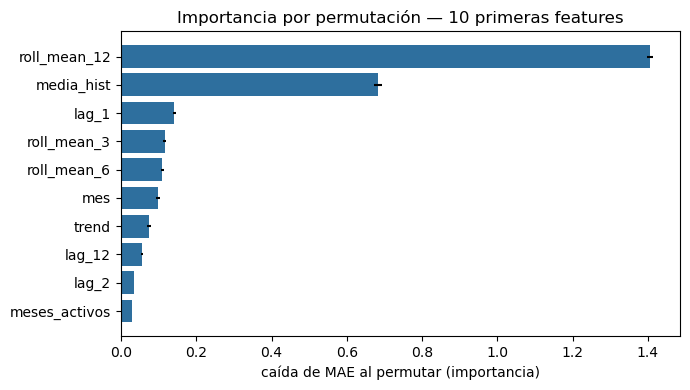

,feature,importancia,std
0,roll_mean_12,1.4063,0.0081
1,media_hist,0.6838,0.0108
2,lag_1,0.1418,0.0049
3,roll_mean_3,0.1160,0.0036
4,roll_mean_6,0.1101,0.0038
5,mes,0.0987,0.0062
6,trend,0.0736,0.0052
7,lag_12,0.0552,0.0021
8,lag_2,0.0353,0.0004
9,meses_activos,0.0296,0.0007


In [11]:
imp = pd.DataFrame(modelo.importancias)
try:
    import matplotlib.pyplot as plt
    top = imp.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(top["feature"], top["importancia"], xerr=top["std"], color="#2e6f9e")
    ax.set_xlabel("caída de MAE al permutar (importancia)")
    ax.set_title("Importancia por permutación — 10 primeras features")
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib no disponible; se muestra la tabla.")
display(imp.head(10))

## 10. La predicción entregada (lo que ve la pestaña *Pronóstico*)

`forecasting.predict` pronostica de forma recursiva los próximos 6 meses de un
municipio × categoría, con la banda de incertidumbre calibrada. El ejemplo reproduce la
consulta Bogotá · Homicidio del tablero (la API añade encima la caché de Redis y el
resolvedor de municipios; el número es este).

,periodo,prediccion,limite_inferior,limite_superior
0,2026-06,139.36,129.20,149.52
1,2026-07,139.36,124.99,153.72
2,2026-08,141.56,123.82,159.29
3,2026-09,142.01,121.49,162.52
4,2026-10,147.29,123.94,170.65
5,2026-11,155.76,129.45,182.07


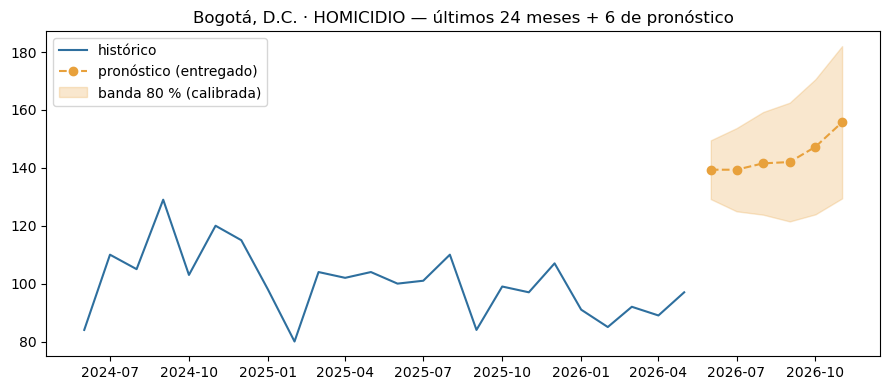

In [12]:
pron = forecasting.predict(serie, "11001", "HOMICIDIO", horizon=6, model=modelo)
tabla_pron = pd.DataFrame(pron)
display(tabla_pron)

try:
    import matplotlib.pyplot as plt
    hist = bogota.sort_values("periodo").tail(24)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hist["periodo"], hist["cantidad"], label="histórico", color="#2e6f9e")
    px = pd.to_datetime(tabla_pron["periodo"])
    ax.plot(px, tabla_pron["prediccion"], "o--", label="pronóstico (entregado)", color="#e8a13c")
    ax.fill_between(px, tabla_pron["limite_inferior"], tabla_pron["limite_superior"],
                    alpha=0.25, color="#e8a13c", label="banda 80 % (calibrada)")
    ax.set_title("Bogotá, D.C. · HOMICIDIO — últimos 24 meses + 6 de pronóstico")
    ax.legend(); plt.tight_layout(); plt.show()
except ImportError:
    pass

## 11. Comprobación: la mezcla 0,7/0,3, desagregada a mano

Para verificar que lo descrito es lo que de verdad recibe el usuario, se reconstruye el
**primer paso** del pronóstico anterior pieza a pieza — tasa predicha por el estimador,
reconversión a conteo con la población, y mezcla con la persistencia — y se compara con el
número que entrega `predict()`.

In [13]:
hist = serie[(serie["cod_municipio"] == "11001") & (serie["categoria"] == "HOMICIDIO")].sort_values("periodo")
persistencia = float(hist[TARGET].iloc[-1])

feats = make_features(forecasting._as_modeling_target(hist, modelo.target_mode))
x = feats.iloc[[-1]][modelo.feature_cols]
tasa_pred = float(np.clip(modelo.estimator.predict(x)[0], 0, None))
poblacion = float(forecasting._pop_series(feats.iloc[[-1]]).iloc[0])
conteo_modelo = tasa_pred * poblacion / forecasting.RATE_SCALE
entregado = forecasting._BLEND_W * conteo_modelo + (1 - forecasting._BLEND_W) * persistencia

print(f"tasa predicha            : {tasa_pred:.4f} por 100.000 hab.")
print(f"población (DANE)         : {poblacion:,.0f}".replace(",", "."))
print(f"conteo del modelo        : {conteo_modelo:.2f}")
print(f"persistencia (último mes): {persistencia:.0f}")
print(f"mezcla = 0,7·{conteo_modelo:.2f} + 0,3·{persistencia:.0f} = {entregado:.2f}")
print(f"predict() entregó        : {pron[0]['prediccion']}")
assert abs(entregado - pron[0]["prediccion"]) < 0.02, "la desagregación no cuadra con predict()"
print("✔ la desagregación coincide con la predicción entregada")

tasa predicha            : 1.9848 por 100.000 hab.
población (DANE)         : 7.935.754
conteo del modelo        : 157.51
persistencia (último mes): 97
mezcla = 0,7·157.51 + 0,3·97 = 139.36
predict() entregó        : 139.36
✔ la desagregación coincide con la predicción entregada


## Cierre

- **Qué es**: un modelo global de *gradient boosting* sobre tasas por 100.000 habitantes,
  cuya predicción se entrega como mezcla 0,7 modelo + 0,3 persistencia, validado con backtest
  walk-forward recursivo y banda calibrada — todo con el código de producción, verificado
  celda a celda.
- **Qué no es**: no estima efectos causales de políticas (el simulador declara sus palancas
  como supuestos del usuario) y pronostica **hechos registrados**, no criminalidad real
  (el subregistro se declara en la documentación).
- **Artefactos**: este notebook escribió su modelo solo en `notebooks/artefactos/`
  (gitignored); `models/forecaster.joblib` y `reports/model_report.json` quedan intactos.
  El entrenamiento oficial es `make docker-pipeline` (dentro del contenedor, con el pin de
  scikit-learn).
- **Referencias**: metodología y bitácora de iteraciones en
  [docs/CRISP-ML-Q.md](../docs/CRISP-ML-Q.md); comparación campeón-retador en
  `vigia challenger`; monitoreo continuo (frescura/deriva/backtest a 12 meses) en
  `vigia health`.